In [ ]:
pip install pandas matplotlib statsmodels scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully")

Files extracted successfully


In [ ]:
import os
os.listdir()

['.config',
 'archive (3).zip',
 'household_power_consumption.txt',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values='?',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df = df[['Date', 'Time', 'Global_active_power']]
df.head()

,Date,Time,Global_active_power
0,16/12/2006,17:24:00,4.216
1,16/12/2006,17:25:00,5.360
2,16/12/2006,17:26:00,5.374
3,16/12/2006,17:27:00,5.388
4,16/12/2006,17:28:00,3.666


In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

In [ ]:
df = df.dropna()

In [ ]:
df = df.set_index('Datetime')

In [ ]:
daily_data = df['Global_active_power'].resample('D').mean()

daily_data.head()

,Global_active_power
Datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


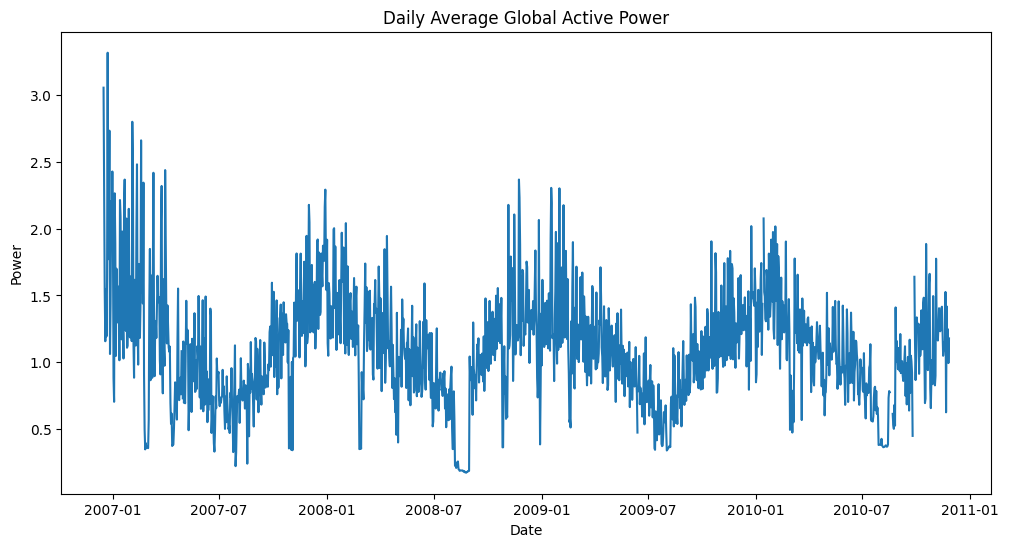

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_data)
plt.title("Daily Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

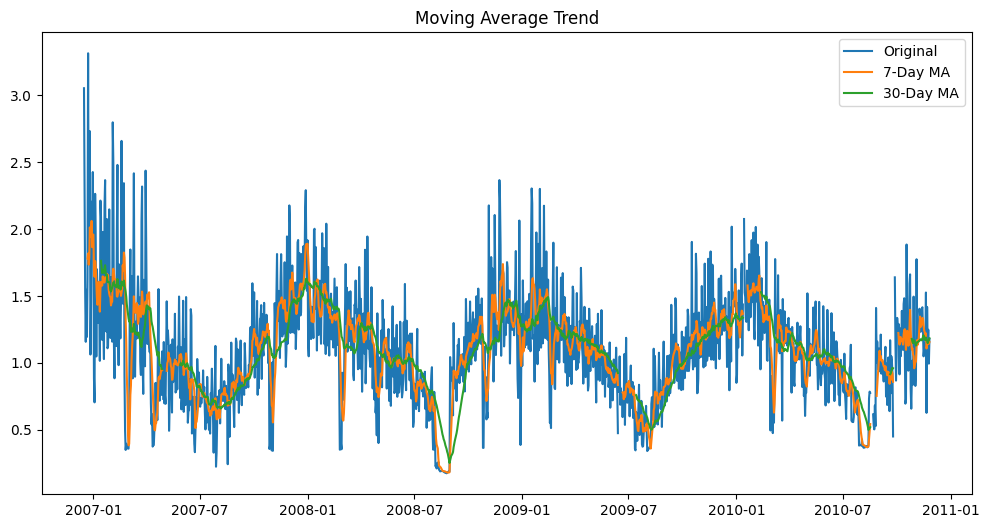

In [ ]:
ma7 = daily_data.rolling(window=7).mean()
ma30 = daily_data.rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_data, label='Original')
plt.plot(ma7, label='7-Day MA')
plt.plot(ma30, label='30-Day MA')
plt.legend()
plt.title("Moving Average Trend")
plt.show()

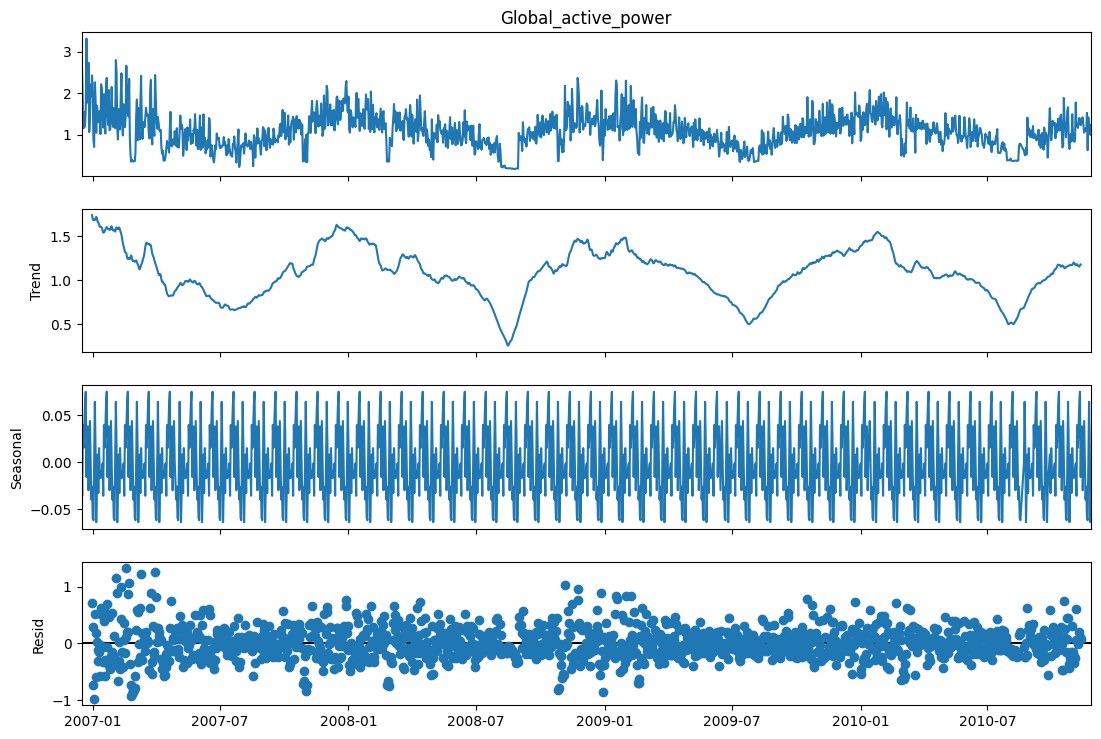

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_data.dropna(), model='additive', period=30)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_data.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.684227530202004
p-value: 0.004340557878211848


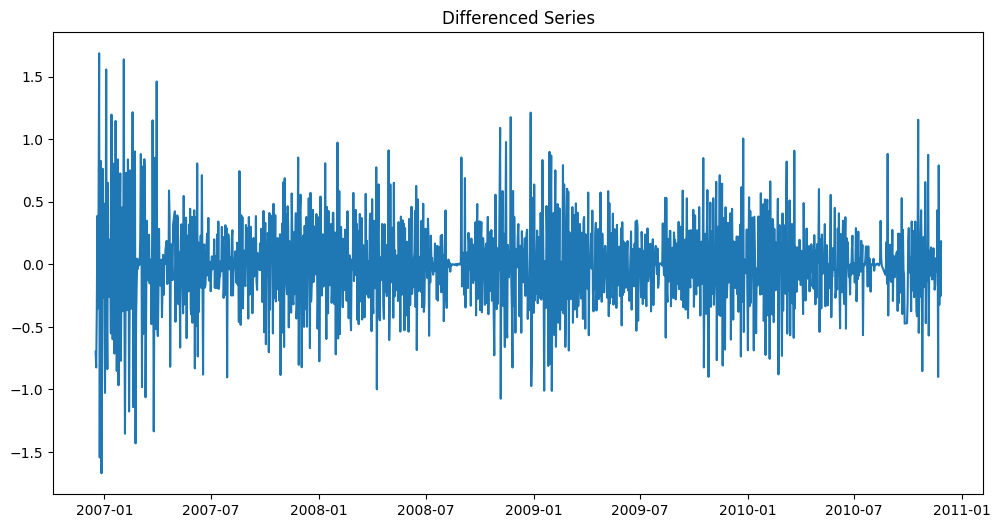

In [ ]:
diff_data = daily_data.diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(diff_data)
plt.title("Differenced Series")
plt.show()

In [ ]:
train_size = int(len(daily_data)*0.8)

train = daily_data[:train_size]
test = daily_data[train_size:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train, trend='add')
fit_es = model_es.fit()

forecast_es = fit_es.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


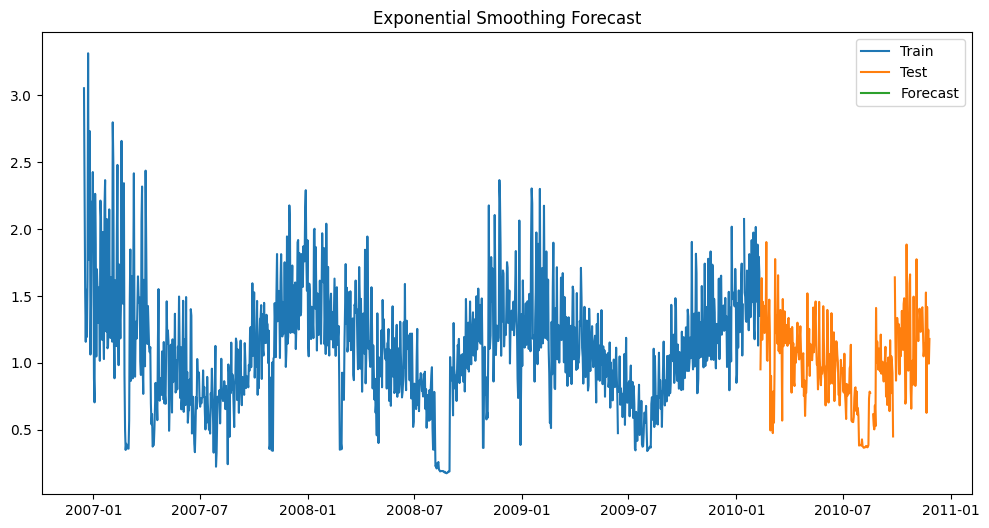

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast_es, label='Forecast')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1,1,1))
fit_arima = model_arima.fit()

forecast_arima = fit_arima.forecast(steps=len(test))

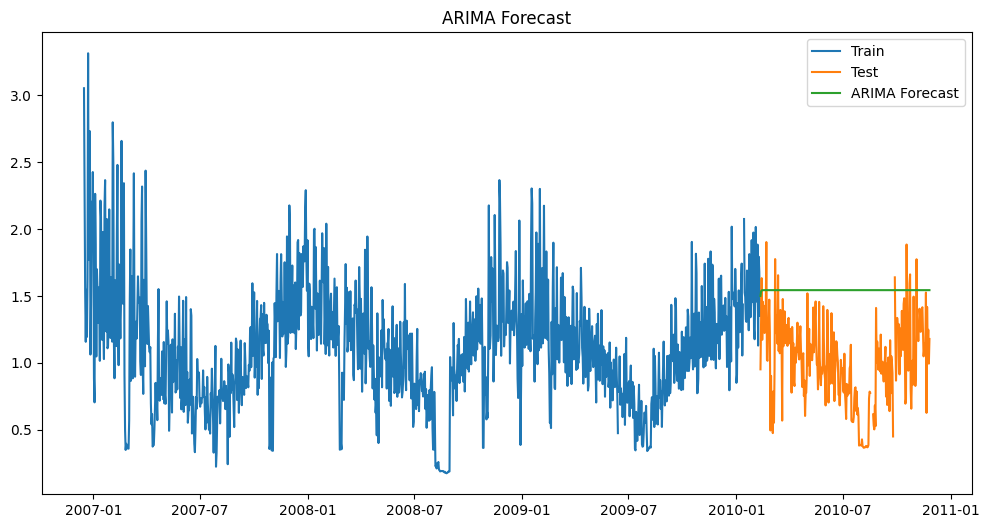

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [ ]:
daily_data = daily_data.dropna()
print("Daily data length:", len(daily_data))
print(daily_data.head())
print(daily_data.tail())

Daily data length: 1433
Datetime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Name: Global_active_power, dtype: float64
Datetime
2010-11-22    1.417733
2010-11-23    1.095511
2010-11-24    1.247394
2010-11-25    0.993864
2010-11-26    1.178230
Name: Global_active_power, dtype: float64


In [ ]:
train_size = int(len(daily_data) * 0.8)

train = daily_data.iloc[:train_size]
test = daily_data.iloc[train_size:]

print("Train length:", len(train))
print("Test length:", len(test))
print(test.head())

Train length: 1146
Test length: 287
Datetime
2010-02-07    1.128964
2010-02-08    1.793221
2010-02-09    1.681203
2010-02-10    1.351315
2010-02-11    0.951228
Name: Global_active_power, dtype: float64


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd

model_es = ExponentialSmoothing(train, trend='add', seasonal=None)
fit_es = model_es.fit()

forecast_es = fit_es.forecast(steps=len(test))
forecast_es = pd.Series(forecast_es.values, index=test.index)

print("ES forecast length:", len(forecast_es))
print(forecast_es.head())

ES forecast length: 287
Datetime
2010-02-07    1.627167
2010-02-08    1.626803
2010-02-09    1.626439
2010-02-10    1.626075
2010-02-11    1.625711
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1,1,1))
fit_arima = model_arima.fit()

forecast_arima = fit_arima.forecast(steps=len(test))
forecast_arima = pd.Series(forecast_arima.values, index=test.index)

print("ARIMA forecast length:", len(forecast_arima))
print(forecast_arima.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA forecast length: 287
Datetime
2010-02-07    1.661924
2010-02-08    1.611131
2010-02-09    1.599515
2010-02-10    1.596858
2010-02-11    1.596250
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
print("NaN in test:", test.isna().sum())
print("NaN in ES forecast:", forecast_es.isna().sum())
print("NaN in ARIMA forecast:", forecast_arima.isna().sum())

NaN in test: 0
NaN in ES forecast: 0
NaN in ARIMA forecast: 0


In [ ]:
results = pd.DataFrame({
    "Actual": test.values,
    "ES_Forecast": forecast_es.values,
    "ARIMA_Forecast": forecast_arima.values
}, index=test.index)

print(results.head())
print("Rows before dropna:", len(results))

results = results.dropna()

print("Rows after dropna:", len(results))
print(results.head())

              Actual  ES_Forecast  ARIMA_Forecast
Datetime                                         
2010-02-07  1.128964     1.627167        1.661924
2010-02-08  1.793221     1.626803        1.611131
2010-02-09  1.681203     1.626439        1.599515
2010-02-10  1.351315     1.626075        1.596858
2010-02-11  0.951228     1.625711        1.596250
Rows before dropna: 287
Rows after dropna: 287
              Actual  ES_Forecast  ARIMA_Forecast
Datetime                                         
2010-02-07  1.128964     1.627167        1.661924
2010-02-08  1.793221     1.626803        1.611131
2010-02-09  1.681203     1.626439        1.599515
2010-02-10  1.351315     1.626075        1.596858
2010-02-11  0.951228     1.625711        1.596250


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_es = mean_absolute_error(results["Actual"], results["ES_Forecast"])
rmse_es = np.sqrt(mean_squared_error(results["Actual"], results["ES_Forecast"]))

mae_arima = mean_absolute_error(results["Actual"], results["ARIMA_Forecast"])
rmse_arima = np.sqrt(mean_squared_error(results["Actual"], results["ARIMA_Forecast"]))

print("Exponential Smoothing MAE:", mae_es)
print("Exponential Smoothing RMSE:", rmse_es)
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

Exponential Smoothing MAE: 0.5758780587146682
Exponential Smoothing RMSE: 0.6451714588145809
ARIMA MAE: 0.5960446830581161
ARIMA RMSE: 0.6650483678750432


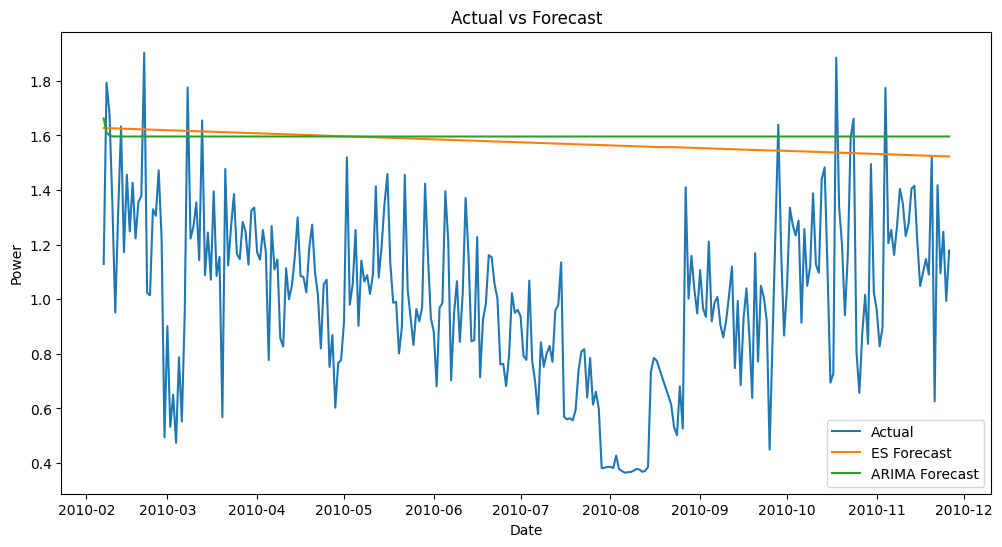

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(results.index, results["Actual"], label="Actual")
plt.plot(results.index, results["ES_Forecast"], label="ES Forecast")
plt.plot(results.index, results["ARIMA_Forecast"], label="ARIMA Forecast")
plt.legend()
plt.title("Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

Actual vs Forecast Comparison

The above graph compares the actual household power consumption values with the forecasted values obtained using Exponential Smoothing and ARIMA models. The actual series shows fluctuations in electricity usage over time, while the forecasting models produce smoother trends. Both models capture the general pattern of the series, although some variations in the actual data are not fully captured by the forecasts.